<a href="https://colab.research.google.com/github/Varada-Kachroo/HimalayanGuardian/blob/main/Part2_UNet_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Computer Vision: U-Net for glaciers & glacial lakes
1. Build image patches (Sentinel-2 + slope from Earth Engine) and masks (ICIMOD lakes + RGI glaciers)
2. Train a U-Net (background / glacier / lake), tracked in MLflow
3. Predict lake area per year for the biggest Tista lakes + South Lhonak
4. Growth % per lake  ->  `processed/lake_growth.csv`, `lake_area_timeseries.csv`, `lake_area_all_years.csv` (Part 3 reads these)

Needs a GPU: Colab -> Runtime -> Change runtime type -> T4 GPU.

**Honest caveats**
- Training masks come from the ~2005 ICIMOD inventory but images are from 2018, so some masks are slightly off (lakes grow/shrink).
  The same model is applied to every year, so a consistent bias mostly cancels in the growth percentage, but treat small
  lakes and small growth numbers with caution.
- Sentinel-2 SR starts in 2017, so the observation window is 2017-2022 (pre-2023: South Lhonak burst in Oct 2023 and shrank).

## 0. Setup

In [ ]:
import sys, os, glob, json, time, warnings
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', timeout_ms=180000)
    get_ipython().system('pip install -q earthengine-api geopandas rasterio mlflow scipy matplotlib pyproj')
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/HimalayanGuardian' if IN_COLAB else os.environ.get('HG_BASE', './HimalayanGuardian')
RAW, PROC, MODELS = f'{BASE}/raw', f'{BASE}/processed', f'{BASE}/processed/models'
PATCH_DIR = f'{PROC}/patches'
for d in (PROC, MODELS, PATCH_DIR):
    os.makedirs(d, exist_ok=True)

EE_PROJECT = 'southern-frame-509805-f2'
PATCH, SCALE = 256, 10            # 256x256 px at 10 m = 2.56 km tiles
TRAIN_YEAR = 2018                 # imagery year for training patches
YEARS = list(range(2017, 2023))   # years for growth measurement
WINDOW = ('10-01', '11-30')       # post-monsoon, clearest + least snow
N_LAKE_PATCHES, N_GLACIER_PATCHES, N_BG_PATCHES = 150, 100, 50
N_GROWTH_LAKES = 60               # biggest Tista lakes (+ South Lhonak) to measure
EPOCHS, BATCH, LR, SEED = 25, 8, 1e-3, 42
BANDS = ['B2', 'B3', 'B4', 'B8', 'B11', 'NDWI', 'NDSI', 'slope']
CLASSES = ['background', 'glacier', 'lake']

import numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import box
from pyproj import Transformer
import ee
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=EE_PROJECT)
rng = np.random.default_rng(SEED)
to_utm = Transformer.from_crs(4326, 32645, always_xy=True)
to_ll = Transformer.from_crs(32645, 4326, always_xy=True)
print('BASE =', BASE)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


BASE = /content/drive/MyDrive/HimalayanGuardian


## 1. Load lake polygons + glacier outlines (same files as Part 1)

In [ ]:
def find_file(name, roots):
    for r in roots:
        hits = glob.glob(os.path.join(r, '**', name), recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f'{name} not found under {roots}')

roots = ['/content', RAW] if IN_COLAB else [RAW]
lakes_gdf = gpd.read_file(find_file('GlacialLake_5basins_HKH.shp', roots))
if lakes_gdf.crs is None:
    lakes_gdf = lakes_gdf.set_crs(4326)
lakes_gdf = lakes_gdf.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)
lakes_gdf['lake_id'] = ['HKH-%05d' % i for i in range(len(lakes_gdf))]      # SAME ids as Part 3
lakes_gdf['area_km2'] = lakes_gdf['Area'] * (1e-6 if lakes_gdf['Area'].median() > 1000 else 1.0)
lakes_utm = lakes_gdf.to_crs(32645)
glac_utm = gpd.read_file(find_file('15_rgi50_SouthAsiaEast.shp', roots)).to_crs(32645)
print('lakes:', len(lakes_utm), '| glaciers:', len(glac_utm))

# South Lhonak = the Part 1 hold-out lake: nearest inventory lake to the burst record
burst = pd.read_csv(f'{PROC}/himalaya_burst_lakes.csv')
lh = burst[burst['lat'].between(27.90, 27.93) & burst['lon'].between(88.18, 88.20)]
lh_lat, lh_lon = (lh['lat'].iloc[0], lh['lon'].iloc[0]) if len(lh) else (27.91, 88.19)
d_m = ((lakes_gdf['Latitude'] - lh_lat) ** 2 + (lakes_gdf['Longitude'] - lh_lon) ** 2) ** 0.5 * 111_000
LHONAK_ID = lakes_gdf.loc[d_m.idxmin(), 'lake_id'] if d_m.min() < 3000 else None
print('South Lhonak lake id:', LHONAK_ID, '| distance (m):', round(float(d_m.min())))

lakes: 25614 | glaciers: 13119
South Lhonak lake id: HKH-08027 | distance (m): 717


## 2. Patch download (Earth Engine) and mask rasterising

In [ ]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

S2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
SLOPE = ee.Terrain.slope(ee.Image('USGS/SRTMGL1_003'))

def feature_image(year, region):
    col = (S2.filterBounds(region).filterDate(f'{year}-{WINDOW[0]}', f'{year}-{WINDOW[1]}')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))
    def mask(img):
        scl = img.select('SCL')
        return img.updateMask(scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)))
    s = col.map(mask).median()
    b = s.select(['B2', 'B3', 'B4', 'B8', 'B11']).divide(10000)
    return (b.addBands(s.normalizedDifference(['B3', 'B8']).rename('NDWI'))
             .addBands(s.normalizedDifference(['B3', 'B11']).rename('NDSI'))
             .addBands(SLOPE.divide(90).rename('slope')).toFloat())

def patch_origin(lon, lat):
    x, y = to_utm.transform(lon, lat)
    x0 = np.floor(x / SCALE - PATCH / 2) * SCALE
    y0 = np.floor(y / SCALE - PATCH / 2) * SCALE
    return x0, y0                                   # lower-left corner (metres, UTM 45N)

def fetch_patch(lon, lat, year, tries=3):
    x0, y0 = patch_origin(lon, lat)
    region = ee.Geometry.Rectangle([x0, y0, x0 + PATCH * SCALE, y0 + PATCH * SCALE], 'EPSG:32645', False)
    img = feature_image(year, region).reproject('EPSG:32645', None, SCALE)
    for t in range(tries):
        try:
            props = img.sampleRectangle(region=region, defaultValue=0).getInfo()['properties']
            arr = np.stack([np.array(props[b], dtype=np.float32) for b in BANDS])
            out = np.zeros((len(BANDS), PATCH, PATCH), np.float32)
            h, w = min(PATCH, arr.shape[1]), min(PATCH, arr.shape[2])
            out[:, :h, :w] = arr[:, :h, :w]
            return out, (x0, y0)
        except Exception as e:
            time.sleep(2 * (t + 1))
    return None, (x0, y0)

def make_mask(x0, y0):
    y1 = y0 + PATCH * SCALE
    tr = from_origin(x0, y1, SCALE, SCALE)
    bx = box(x0, y0, x0 + PATCH * SCALE, y1)
    lab = np.zeros((PATCH, PATCH), np.uint8)
    for gdf, val in ((glac_utm, 1), (lakes_utm, 2)):          # lake overrides glacier
        hit = gdf.iloc[list(gdf.sindex.intersection(bx.bounds))]
        if len(hit):
            m = rasterize([(g, 1) for g in hit.geometry], out_shape=(PATCH, PATCH), transform=tr, fill=0, dtype='uint8')
            lab[m == 1] = val
    return lab

### 2b. Choose patch centres and download (cached in Drive — safe to re-run)

In [ ]:
cache = f'{PATCH_DIR}/train_patches_{TRAIN_YEAR}.npz'
if os.path.exists(cache):
    z = np.load(cache, allow_pickle=True)
    Xall, Yall, meta = z['X'], z['Y'], pd.DataFrame(z['meta'].tolist())
    print('Loaded cached patches:', Xall.shape)
else:
    tista = lakes_gdf[lakes_gdf['Basin'] == 'Tista']
    tista = tista[tista['lake_id'] != LHONAK_ID]                      # hold South Lhonak OUT of training
    centres = []
    for r in tista.sample(min(N_LAKE_PATCHES, len(tista)), random_state=SEED).itertuples():
        centres.append((r.Longitude, r.Latitude, 'lake'))
    sik = glac_utm.cx[to_utm.transform(87.9, 27.2)[0]:to_utm.transform(89.0, 28.2)[0],
                      to_utm.transform(87.9, 27.2)[1]:to_utm.transform(89.0, 28.2)[1]]
    for g in sik.sample(min(N_GLACIER_PATCHES, len(sik)), random_state=SEED).geometry.centroid:
        lo, la = to_ll.transform(g.x, g.y); centres.append((lo, la, 'glacier'))
    for _ in range(N_BG_PATCHES):
        centres.append((float(rng.uniform(87.9, 89.0)), float(rng.uniform(27.2, 28.2)), 'background'))
    # drop any patch that would overlap South Lhonak
    centres = [c for c in centres if abs(c[0] - lh_lon) > 0.06 or abs(c[1] - lh_lat) > 0.06]

    Xs, Ys, M = [], [], []
    for i, (lo, la, kind) in enumerate(centres):
        arr, (x0, y0) = fetch_patch(lo, la, TRAIN_YEAR)
        if arr is None or np.isnan(arr).all() or (arr[:5].sum() == 0):
            continue
        Xs.append(arr.astype(np.float16)); Ys.append(make_mask(x0, y0))
        M.append({'lon': lo, 'lat': la, 'kind': kind})
        if i % 25 == 0:
            print(f'{i}/{len(centres)} patches, kept {len(Xs)}')
    Xall, Yall, meta = np.stack(Xs), np.stack(Ys), pd.DataFrame(M)
    np.savez_compressed(cache, X=Xall, Y=Yall, meta=np.array(M, dtype=object))
    print('Saved', Xall.shape, 'to', cache)

print('Class pixel share:', {c: round(float((Yall == i).mean()), 4) for i, c in enumerate(CLASSES)})

0/292 patches, kept 1
25/292 patches, kept 26
50/292 patches, kept 51
75/292 patches, kept 76
100/292 patches, kept 101
125/292 patches, kept 126
150/292 patches, kept 151
175/292 patches, kept 176
200/292 patches, kept 201
225/292 patches, kept 226
250/292 patches, kept 251
275/292 patches, kept 276
Saved (292, 8, 256, 256) to /content/drive/MyDrive/HimalayanGuardian/processed/patches/train_patches_2018.npz
Class pixel share: {'background': 0.798, 'glacier': 0.1864, 'lake': 0.0156}


## 3. U-Net

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '(use a GPU runtime - CPU training will be very slow)')

def block(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                         nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, c_in=len(BANDS), n_cls=3, f=(32, 64, 128, 256)):
        super().__init__()
        self.e1, self.e2, self.e3, self.e4 = block(c_in, f[0]), block(f[0], f[1]), block(f[1], f[2]), block(f[2], f[3])
        self.pool = nn.MaxPool2d(2)
        self.u3, self.d3 = nn.ConvTranspose2d(f[3], f[2], 2, 2), block(f[3], f[2])
        self.u2, self.d2 = nn.ConvTranspose2d(f[2], f[1], 2, 2), block(f[2], f[1])
        self.u1, self.d1 = nn.ConvTranspose2d(f[1], f[0], 2, 2), block(f[1], f[0])
        self.out = nn.Conv2d(f[0], n_cls, 1)
    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(self.pool(e1)); e3 = self.e3(self.pool(e2)); e4 = self.e4(self.pool(e3))
        d3 = self.d3(torch.cat([self.u3(e4), e3], 1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

# block split by 0.1 degree cells so neighbouring patches never straddle train/val
cell = (meta['lat'] // 0.1).astype(int).astype(str) + '_' + (meta['lon'] // 0.1).astype(int).astype(str)
ucells = cell.unique(); rng.shuffle(ucells)
val_cells = set(ucells[:max(1, int(0.2 * len(ucells)))])
is_val = cell.isin(val_cells).values
Xtr, Ytr, Xva, Yva = Xall[~is_val].astype(np.float32), Yall[~is_val], Xall[is_val].astype(np.float32), Yall[is_val]
MEAN = Xtr.mean(axis=(0, 2, 3), keepdims=True)[0]; STD = Xtr.std(axis=(0, 2, 3), keepdims=True)[0] + 1e-6
print('train patches:', len(Xtr), '| val patches:', len(Xva))

class Seg(Dataset):
    def __init__(self, X, Y, aug): self.X, self.Y, self.aug = X, Y, aug
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x, y = (self.X[i] - MEAN) / STD, self.Y[i]
        if self.aug:
            k = np.random.randint(4); x, y = np.rot90(x, k, (1, 2)), np.rot90(y, k)
            if np.random.rand() < .5: x, y = x[:, :, ::-1], y[:, ::-1]
        return torch.from_numpy(np.ascontiguousarray(x)).float(), torch.from_numpy(np.ascontiguousarray(y)).long()

tr_dl = DataLoader(Seg(Xtr, Ytr, True), batch_size=BATCH, shuffle=True)
va_dl = DataLoader(Seg(Xva, Yva, False), batch_size=BATCH)

freq = np.array([(Ytr == c).mean() for c in range(3)]) + 1e-6
cls_w = torch.tensor((1 / np.sqrt(freq)) / (1 / np.sqrt(freq)).sum() * 3, dtype=torch.float32, device=DEVICE)

def dice_loss(logits, y):
    p = F.softmax(logits, 1); oh = F.one_hot(y, 3).permute(0, 3, 1, 2).float()
    inter = (p * oh).sum((0, 2, 3)); den = p.sum((0, 2, 3)) + oh.sum((0, 2, 3))
    return 1 - ((2 * inter + 1) / (den + 1)).mean()

def iou_per_class(pred, y):
    return [float(((pred == c) & (y == c)).sum() / max(((pred == c) | (y == c)).sum(), 1)) for c in range(3)]

device: cuda (use a GPU runtime - CPU training will be very slow)
train patches: 236 | val patches: 56


## 4. Train (MLflow)

In [ ]:
import mlflow
mlflow.set_tracking_uri(f'sqlite:///{BASE}/mlflow.db'); mlflow.set_experiment('glof_unet')
model = UNet().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
best, best_state = -1, None

with mlflow.start_run(run_name='unet_glacier_lake'):
    mlflow.log_params({'epochs': EPOCHS, 'batch': BATCH, 'lr': LR, 'train_year': TRAIN_YEAR, 'bands': ','.join(BANDS),
                       'n_train': len(Xtr), 'n_val': len(Xva)})
    for ep in range(EPOCHS):
        model.train(); tl = 0
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=cls_w) + dice_loss(logits, y)
            opt.zero_grad(); loss.backward(); opt.step(); tl += loss.item() * len(x)
        sched.step()
        model.eval(); P, Y = [], []
        with torch.no_grad():
            for x, y in va_dl:
                P.append(model(x.to(DEVICE)).argmax(1).cpu()); Y.append(y)
        P, Y = torch.cat(P), torch.cat(Y)
        ious = iou_per_class(P, Y); score = (ious[1] + ious[2]) / 2
        mlflow.log_metrics({'train_loss': tl / len(Xtr), 'val_iou_glacier': ious[1], 'val_iou_lake': ious[2], 'val_miou_glacier_lake': score}, step=ep)
        if score > best:
            best, best_state = score, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == EPOCHS - 1:
            print(f'epoch {ep:02d} loss {tl / len(Xtr):.3f} | val IoU glacier {ious[1]:.3f} lake {ious[2]:.3f}')
    model.load_state_dict(best_state)
    torch.save({'state': best_state, 'mean': MEAN, 'std': STD, 'bands': BANDS}, f'{MODELS}/unet_glacier_lake.pt')
    mlflow.log_metric('best_val_miou_glacier_lake', best)
    mlflow.log_artifact(f'{MODELS}/unet_glacier_lake.pt')
print('Best val mean IoU (glacier, lake):', round(best, 3), '| saved to', f'{MODELS}/unet_glacier_lake.pt')

2026/10/09 08:38:12 INFO mlflow.tracking.fluent: Experiment with name 'glof_unet' does not exist. Creating a new experiment.


epoch 00 loss 1.258 | val IoU glacier 0.531 lake 0.104
epoch 05 loss 0.709 | val IoU glacier 0.597 lake 0.562
epoch 10 loss 0.621 | val IoU glacier 0.550 lake 0.657
epoch 15 loss 0.590 | val IoU glacier 0.670 lake 0.657
epoch 20 loss 0.507 | val IoU glacier 0.683 lake 0.657
epoch 24 loss 0.555 | val IoU glacier 0.686 lake 0.652
Best val mean IoU (glacier, lake): 0.678 | saved to /content/drive/MyDrive/HimalayanGuardian/processed/models/unet_glacier_lake.pt


## 5. Lake area per year  ->  growth %

In [ ]:
from scipy import ndimage
model.eval()

def predict_mask(arr):
    x = torch.from_numpy((arr - MEAN) / STD).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return model(x).argmax(1)[0].cpu().numpy()

def centre_lake_area_km2(pred):
    """Area of the lake blob nearest the patch centre (patches are centred on the lake)."""
    lab, n = ndimage.label(pred == 2)
    if n == 0:
        return 0.0
    c = PATCH // 2
    yy, xx = np.nonzero(lab)
    d = (yy - c) ** 2 + (xx - c) ** 2
    j = d.argmin()
    if d[j] > 20 ** 2:                       # nothing within 200 m of the centre
        return 0.0
    return float((lab == lab[yy[j], xx[j]]).sum() * SCALE * SCALE / 1e6)

tista_lakes = lakes_gdf[lakes_gdf['Basin'] == 'Tista'].sort_values('area_km2', ascending=False)
targets = tista_lakes.head(N_GROWTH_LAKES)
if LHONAK_ID and LHONAK_ID not in set(targets['lake_id']):
    targets = pd.concat([targets, lakes_gdf[lakes_gdf['lake_id'] == LHONAK_ID]])
print('Lakes to measure:', len(targets), '| years:', YEARS, '| ~', len(targets) * len(YEARS), 'downloads')

hist_path = f'{PROC}/lake_area_all_years.csv'
done = pd.read_csv(hist_path) if os.path.exists(hist_path) else pd.DataFrame(columns=['lake_id', 'lat', 'lon', 'year', 'area_km2'])
have = set(zip(done['lake_id'], done['year']))
rows = done.to_dict('records')
n_new = 0
for r in targets.itertuples():
    for yr in YEARS:
        if (r.lake_id, yr) in have:
            continue
        arr, _ = fetch_patch(r.Longitude, r.Latitude, yr)
        if arr is None or arr[:5].sum() == 0:
            continue                        # no usable imagery that year -> skip, never fake a value
        rows.append({'lake_id': r.lake_id, 'lat': r.Latitude, 'lon': r.Longitude, 'year': yr,
                     'area_km2': round(centre_lake_area_km2(predict_mask(arr)), 5)})
        n_new += 1
    if n_new and n_new % 40 == 0:
        pd.DataFrame(rows).to_csv(hist_path, index=False)      # checkpoint
hist = pd.DataFrame(rows); hist.to_csv(hist_path, index=False)
print('Saved', hist_path, '| rows:', len(hist))

Lakes to measure: 60 | years: [2017, 2018, 2019, 2020, 2021, 2022] | ~ 360 downloads
Saved /content/drive/MyDrive/HimalayanGuardian/processed/lake_area_all_years.csv | rows: 360


      lake_id     lat     lon  area_first_km2  area_last_km2  growth_pct     period
31  HKH-08780  27.956  88.714         0.07010        0.19010      171.18  2017-2022
36  HKH-09038  27.974  88.423         0.15080        0.40665      169.66  2017-2022
10  HKH-07873  27.894  88.192         0.08835        0.17215       94.85  2017-2022
18  HKH-08120  27.678  88.378         0.19145        0.32845       71.56  2017-2022
15  HKH-08056  27.852  88.242         0.18245        0.30185       65.44  2017-2022
39  HKH-09158  27.956  88.358         0.21990        0.34190       55.48  2017-2022
5   HKH-07655  27.950  88.353         0.27270        0.39045       43.18  2017-2022
21  HKH-08201  27.964  88.796         0.27455        0.38540       40.38  2017-2022
57  HKH-11433  27.723  88.690         0.12220        0.16900       38.30  2017-2022
8   HKH-07741  27.895  88.761         0.41790        0.57125       36.70  2017-2022

South Lhonak area by year (km2):
 year  area_km2
 2017    1.4294
 2018    1

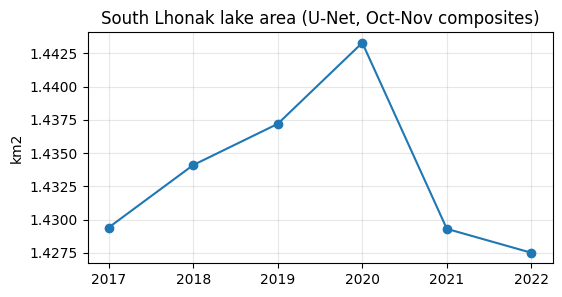

In [ ]:
def growth(g):
    g = g.sort_values('year')
    if g['year'].nunique() < 3:
        return pd.Series({'growth_pct': np.nan})
    first, last = g['area_km2'].head(2).mean(), g['area_km2'].tail(2).mean()
    return pd.Series({'area_first_km2': first, 'area_last_km2': last,
                      'growth_pct': np.nan if first < 0.01 else round((last - first) / first * 100, 2),
                      'period': f"{int(g['year'].min())}-{int(g['year'].max())}"})

gr = hist.groupby(['lake_id', 'lat', 'lon']).apply(growth).reset_index()
gr.to_csv(f'{PROC}/lake_growth.csv', index=False)          # Part 3 reads: lat, lon, growth_pct
print(gr.sort_values('growth_pct', ascending=False).head(10).to_string())

if LHONAK_ID and (hist['lake_id'] == LHONAK_ID).any():
    lts = hist[hist['lake_id'] == LHONAK_ID][['year', 'area_km2']].sort_values('year')
    lts.to_csv(f'{PROC}/lake_area_timeseries.csv', index=False)   # Part 3 reads: year, area_km2
    print('\nSouth Lhonak area by year (km2):'); print(lts.to_string(index=False))
    g_l = gr[gr['lake_id'] == LHONAK_ID]['growth_pct'].values
    print('South Lhonak growth over the period:', g_l)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 3)); plt.plot(lts['year'], lts['area_km2'], marker='o')
    plt.title('South Lhonak lake area (U-Net, Oct-Nov composites)'); plt.ylabel('km2'); plt.grid(alpha=.3)
    plt.savefig(f'{PROC}/south_lhonak_area.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print('South Lhonak not measured - check LHONAK_ID / imagery availability.')

Done. Outputs: `processed/lake_growth.csv`, `lake_area_timeseries.csv`, `lake_area_all_years.csv`, `models/unet_glacier_lake.pt`.
Next: run Part 3 — it picks these files up automatically.